Device: cpu


  0%|          | 0/200 [00:00<?, ?it/s]


Initial NRMSE: 0.1174
Initial PSNR: 21.61 dB
Initial SSIM: 0.6958

Result NRMSE: 0.0667
Result PSNR: 26.55 dB
Result SSIM: 0.8098


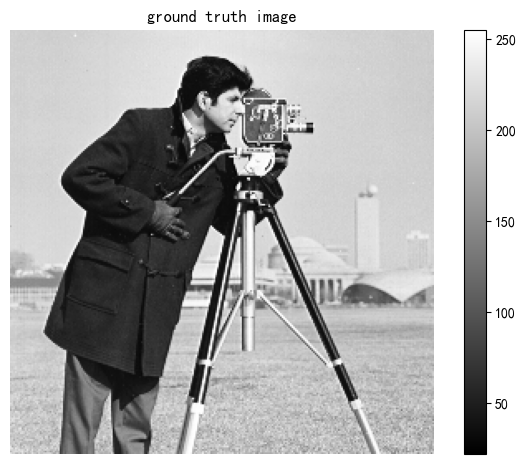

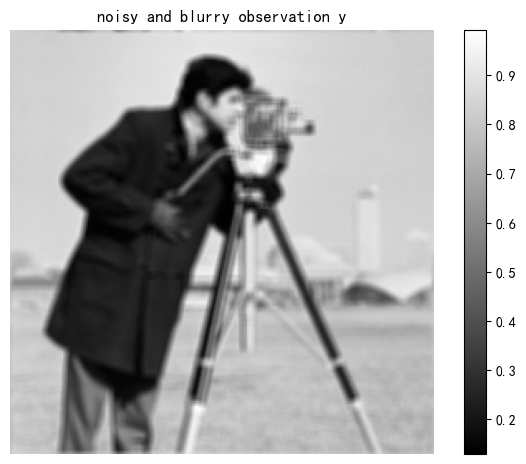

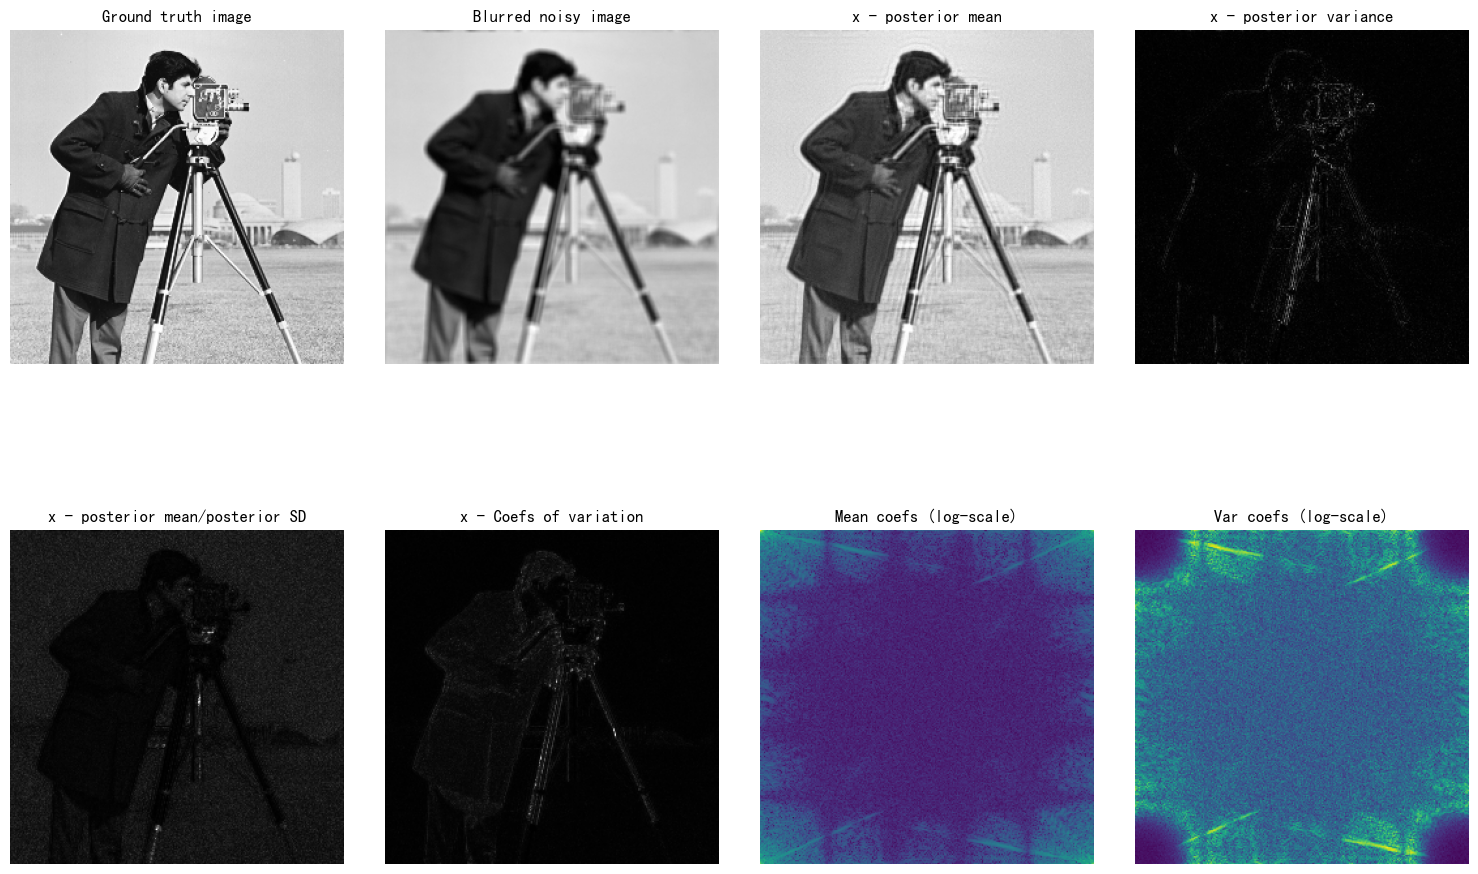

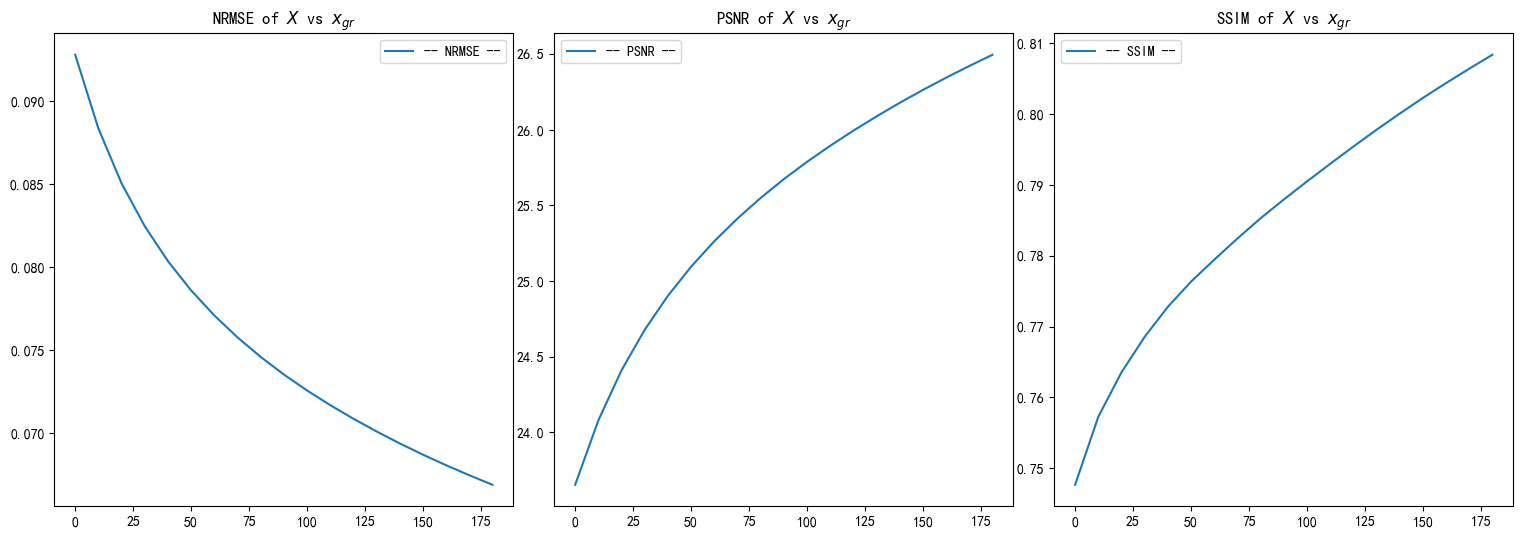

In [1]:
"""
实验4.6 PnP-ULA后验采样（去噪器先验）
对应章节：4.3（ULA应用）、4.7（后验统计、收敛监控）
素材来源：Mathematics.../Teaching Unit 2/labs/lab2_PnP_sol.ipynb
  - Cell 3-6: 导入、图像加载、模糊算子、含噪观测
  - Cell 8-10: 似然函数、梯度、Lipschitz常数
  - Cell 11-12: 去噪器加载、算法参数
  - Cell 13: Markov_kernel 函数（PnP-ULA和PPnP-ULA）
  - Cell 14-15: 步长选择、初始化
  - Cell 16-17: 主采样循环（含welford在线统计）
  - Cell 18-20: 结果评估与可视化
  辅助模块：lab2_PnP.zip -> sampling_tools/ (welford, blur_operators, measures, plots)

运行前提：
  1. 解压 lab2_PnP.zip
  2. 修改下方 PARENT_DIR 为本地解压路径
  3. 需要GPU和预训练RealSN-DnCNN模型
"""

import math
import torch
import numpy as np
import time as time
from tqdm.auto import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import logging

# ====== 解决中文乱码的核心代码 ======
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", message=".*U\\+2212.*")
warnings.filterwarnings("ignore", message=".*glyph.*")
plt.rcParams['font.family'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# ========================================================

import sys
import os

# ★ sampling_tools 已拷贝到当前目录，无需外部路径
PARENT_DIR = os.path.dirname(os.path.abspath(''))  # 当前目录
if PARENT_DIR not in sys.path:
    sys.path.append(PARENT_DIR)

from sampling_tools import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ============================================================
# 加载图像（取自 lab2_PnP_sol Cell 5，cman.png已拷贝到当前目录）
# ============================================================
SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
im = np.array(Image.open(os.path.join(SCRIPT_DIR, "cman.png")))
plot_im(im, "ground truth image")

x = torch.Tensor(im/255.).to(device)

# ============================================================
# 模糊算子（取自 lab2_PnP_sol Cell 6）
# ============================================================
kernel_len = [5,5]
size = [im.shape[0],im.shape[1]]
type_blur = "uniform"
A, AT, AAT_norm = blur_operators(kernel_len, size, type_blur, device)

# ============================================================
# 含噪观测（取自 lab2_PnP_sol Cell 7）
# ============================================================
y0 = A(x)

BSNRdb = 40
sigma = torch.linalg.matrix_norm(A(x)-torch.mean(A(x)), ord='fro')/math.sqrt(torch.numel(x)*10**(BSNRdb/10))

y = y0 + sigma * torch.randn_like(x)
plot_im(y, "noisy and blurry observation y")

# ============================================================
# 似然与梯度（取自 lab2_PnP_sol Cell 8-10）
# ============================================================
f = lambda x,A : (torch.linalg.matrix_norm(y-A(x), ord='fro')**2.0)/(2.0*sigma**2)
gradf = lambda x,A,AT : AT(A(x)-y)/sigma**2
L_y = AAT_norm/(sigma**2)

# ============================================================
# 去噪器（取自 lab2_PnP_sol Cell 11）
# ============================================================
L_net = 1.0
model = load_model(os.path.join(SCRIPT_DIR, 'Pretrained_models', 'RealSN_DnCNN_noise5.pth'), device)
denoise = lambda x: (x - model(x[None][None].to(device))[0][0]).detach()

# ============================================================
# 算法参数（取自 lab2_PnP_sol Cell 12）
# ============================================================
alpha = 1
eps =  (5/255)**2
max_lambd = 1.0/((2.0*alpha*L_net)/eps+4.0*L_y)
lambd_frac = 0.99
lambd = max_lambd*lambd_frac

C_upper_lim = torch.tensor(1).to(device)
C_lower_lim = torch.tensor(0).to(device)

# ============================================================
# PnP-ULA / PPnP-ULA Markov核（取自 lab2_PnP_sol Cell 13）
# ============================================================
projbox = lambda x: torch.clamp(x, min = C_lower_lim, max = C_upper_lim)

def Markov_kernel(X, delta, projected):
    if projected:
        return projbox(X - delta * gradf(X,A,AT) + alpha*delta/eps*(denoise(X)-X) + math.sqrt(2*delta) * torch.randn_like(X))
    else:
        return X - delta * gradf(X,A,AT) + alpha*delta/eps*(denoise(X)-X) + delta/lambd*(projbox(X)-X) + math.sqrt(2*delta) * torch.randn_like(X)

# ============================================================
# 步长选择（取自 lab2_PnP_sol Cell 14）
# ============================================================
projected = True

if projected:
    delta_max = (1.0)/(L_net/eps+L_y)
else:
    delta_max = (1.0/3.0)/((alpha*L_net)/eps+L_y+1/lambd)
delta_frac = 0.99
delta = delta_max*delta_frac

# ============================================================
# 初始化（取自 lab2_PnP_sol Cell 15-16）
# ============================================================
maxit = 200        # 原始10000，此处缩小以便CPU快速演示
burnin = np.int64(maxit*0.05)
n_samples = np.int64(40)  # 原始2000，按比例缩小
X = y.clone()
MC_X = []
thinned_trace_counter = 0
thinning_step = np.int64(maxit/n_samples)

nrmse_values = []
psnr_values = []
ssim_values = []

# ============================================================
# 主采样循环（取自 lab2_PnP_sol Cell 17）
# ============================================================
start_time = time.time()
for i_x in tqdm(range(maxit)):

    # Update X
    X = Markov_kernel(X, delta, projected=projected)

    if i_x == burnin:
        # Initialise recording of sample summary statistics after burnin period
        post_meanvar = welford(X)
        absfouriercoeff = welford(torch.fft.fft2(X).abs())
        count=0
    elif i_x > burnin:
        # update the sample summary statistics
        post_meanvar.update(X)
        absfouriercoeff.update(torch.fft.fft2(X).abs())

        # collect quality measurements
        current_mean = post_meanvar.get_mean()
        nrmse_values.append(NRMSE(x, current_mean))
        psnr_values.append(PSNR(x, current_mean))
        ssim_values.append(SSIM(x, current_mean))

        # collect thinned trace
        if count == thinning_step-1:
            MC_X.append(X.detach().cpu().numpy())
            count = 0
        else:
            count += 1

end_time = time.time()
elapsed = end_time - start_time

# ============================================================
# 结果评估（取自 lab2_PnP_sol Cell 18-20）
# ============================================================
print(f"\nInitial NRMSE: {NRMSE(x,y):.4f}")
print(f"Initial PSNR: {PSNR(x,y):.2f} dB")
print(f"Initial SSIM: {SSIM(x,y):.4f}")

print(f"\nResult NRMSE: {NRMSE(post_meanvar.get_mean(),x):.4f}" )
print(f"Result PSNR: {PSNR(post_meanvar.get_mean(),x):.2f} dB")
print(f"Result SSIM: {SSIM(x,post_meanvar.get_mean()):.4f}")

plots(x, y, post_meanvar, absfouriercoeff, nrmse_values, psnr_values, ssim_values)
